# Article Embeddings (quick & dirty)
Pulls all articles from Neo4j, embeds with `nomic-embed-text-v2-moe` via Ollama, stores back on Article nodes.

In [ ]:
import ollama
from Pipelines.db.db import get_driver

## 1. Pull articles from Neo4j

In [80]:
driver = get_driver()

with driver.session() as session:
    result = session.run("""
        MATCH (a:Article)
        WHERE a.embedding IS NULL
        RETURN a.url AS url, a.title AS title, a.full_text AS full_text
    """)
    articles = result.data()

print(f"{len(articles)} articles to embed")

0 articles to embed


## 2. Embed

In [81]:
MODEL = "nomic-embed-text-v2-moe"

def embed(article: dict) -> list[float]:
    # Combine title + body; fall back to title only if no full_text
    text = (article["title"] or "")# + "\n\n" + (article["full_text"] or "")
    text = text.strip()
    resp = ollama.embeddings(model=MODEL, prompt=text)
    return resp["embedding"]

embedded = []
for art in articles:
    try:
        vec = embed(art)
        embedded.append({"url": art["url"], "embedding": vec})
    except Exception as e:
        print(f"SKIP {art['url']}: {e}")

print(f"Embedded {len(embedded)}/{len(articles)}")

Embedded 0/0


## 3. Store embeddings back in Neo4j

In [82]:
BATCH_SIZE = 50

def store_batch(session, batch):
    session.run("""
        UNWIND $rows AS row
        MATCH (a:Article {url: row.url})
        SET a.embedding = row.embedding
    """, rows=batch)

with driver.session() as session:
    for i in range(0, len(embedded), BATCH_SIZE):
        store_batch(session, embedded[i:i + BATCH_SIZE])

print("Done.")

Done.


## 4. Quick sanity check

In [83]:
with driver.session() as session:
    r = session.run("""
        MATCH (a:Article)
        RETURN
            count(a) AS total,
            count(a.embedding) AS with_embedding
    """)
    print(r.single().data())

{'total': 300, 'with_embedding': 300}


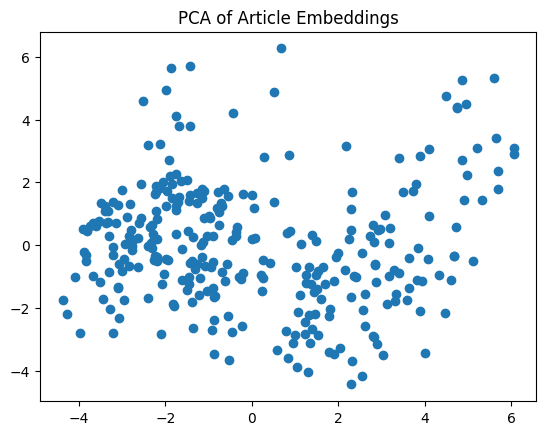

In [84]:
import numpy as np
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
with driver.session() as session:
    result = session.run("""
        MATCH (a:Article)
        WHERE a.embedding IS NOT NULL
        RETURN a.embedding AS embedding, a.title AS title
    """)
    
    records = list(result)

    embeddings_list = [r["embedding"] for r in records]
    articles = [{"embedding": r["embedding"], "title": r["title"]} for r in records]

embeddings = np.array(embeddings_list)
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title('PCA of Article Embeddings')
plt.show()

In [85]:
len(articles)

300

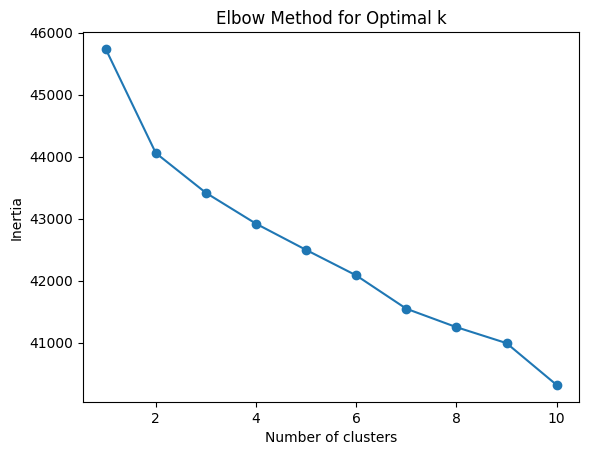

In [86]:
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 11)
for k in k_range:
	kmeans = KMeans(n_clusters=k, random_state=42)
	kmeans.fit(embeddings)
	inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

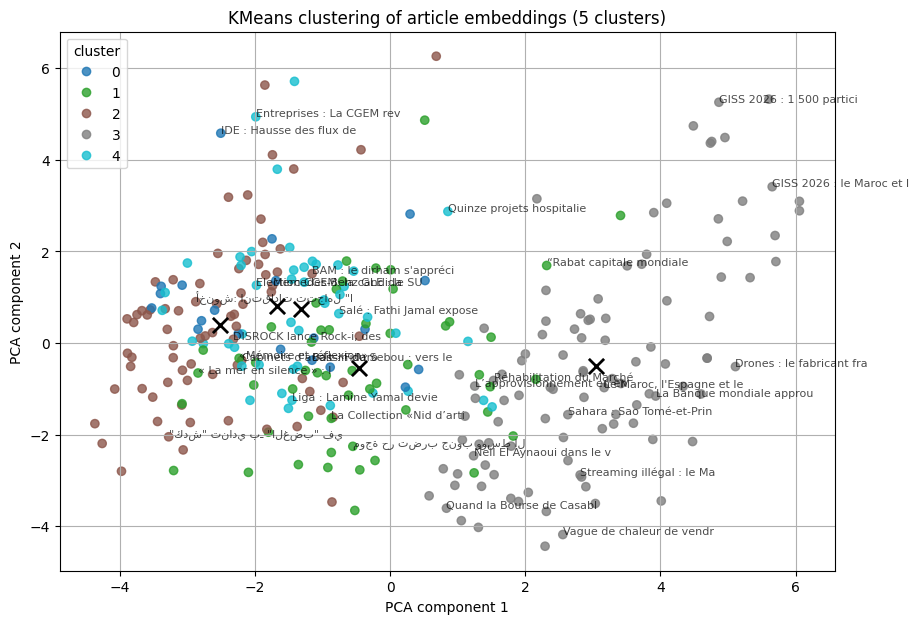

In [91]:
ANNOT = True


from sklearn.cluster import KMeans

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

# project cluster centers to PCA space for plotting
centers_2d = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(10, 7))

scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="tab10", alpha=0.8)
# Annotate only 50% of points to avoid clutter
for i, (x, y) in enumerate(reduced):
	if i % 10 == 0 and ANNOT:
		plt.annotate(articles[i]['title'][:25], (x, y), fontsize=8, alpha=0.7)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c="black", marker="x", s=120, linewidths=2)
plt.title(f"KMeans clustering of article embeddings ({n_clusters} clusters)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(*scatter.legend_elements(), title="cluster")
plt.grid(True)
plt.show()

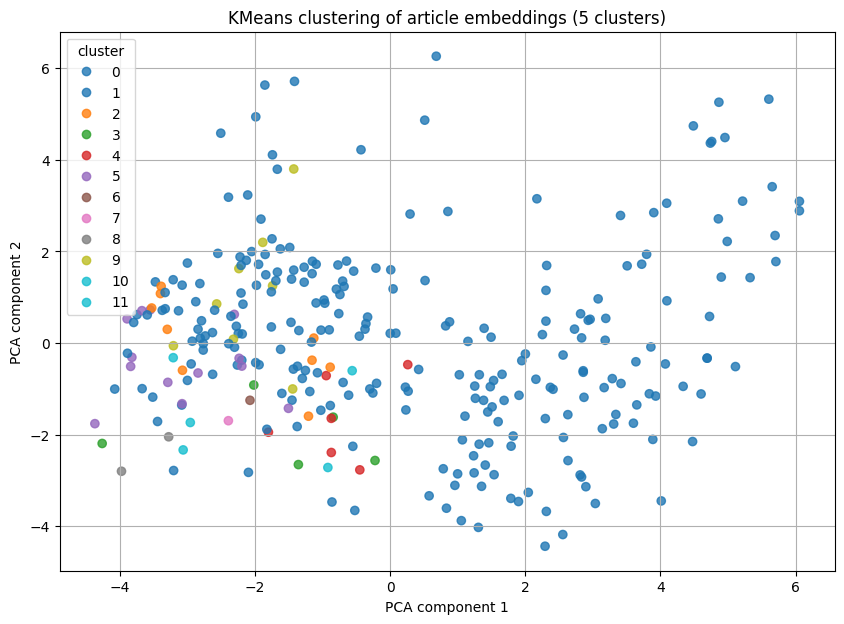

In [88]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize



model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.85,  # controls cut level
    metric='cosine',
    linkage='average'
)

X = normalize(embeddings)


labels = model.fit_predict(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="tab10", alpha=0.8)
plt.title(f"KMeans clustering of article embeddings ({n_clusters} clusters)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(*scatter.legend_elements(), title="cluster")
plt.grid(True)
plt.show()